In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error
import joblib

**Feature Engineering**

In [3]:
df = pd.read_csv("aapl.us.txt" , parse_dates=['Date'] , index_col='Date')

# #creat target (Y): tommorow's price
df['Target_Pct_Return'] = df['Close'].pct_change().shift(-1)

# # #lag features
df['Close_lag1'] = df['Close'].shift(1) #yesterday close
df['Close_lag2'] = df['Close'].shift(2) #2 days ago close
df['Volume_lag1'] = df['Volume'].shift(3) #yesterday lag

#Calculate RSI (Relative Strength Index) Feature
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

#Calculate MACD (Moving Average Convergence Divergence) Feature
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2

#drop nan values
df_ml = df.dropna().copy()

print(f"Dataset shape after feature engineering: {df_ml.shape}")
df_ml[['Close', 'Target_Pct_Return', 'Close_lag1', 'RSI_14', 'MACD']].head()

Dataset shape after feature engineering: (8350, 12)


,Close,Target_Pct_Return,Close_lag1,RSI_14,MACD
Date,,,,,
1984-09-26,0.41111,0.000000,0.41618,44.335019,-0.000606
1984-09-27,0.41111,-0.025054,0.41111,44.335019,-0.001792
1984-09-28,0.40081,-0.022330,0.41111,41.479206,-0.003523
1984-10-01,0.39186,0.006558,0.40081,34.737966,-0.005552
1984-10-02,0.39443,0.016175,0.39186,40.244012,-0.006874


In [4]:
df = pd.read_csv("aapl.us.txt" , parse_dates=['Date'] , index_col='Date')

f_cols = ['Close', 'Close_lag1', 'RSI_14', 'MACD']

x = df_ml[f_cols]
y = df_ml['Target_Pct_Return']

# split based on cut off date
cutoff_date = '2015-01-01'

x_train = x.loc[:cutoff_date]
y_train = y.loc[:cutoff_date]

x_test = x.loc[cutoff_date:]
y_test = y.loc[cutoff_date:]

print(f"Training set size: {x_train.shape[0]} rows")
print(f"Testing set size: {x_test.shape[0]} rows")

Training set size: 7629 rows
Testing set size: 721 rows


**Ramdom Forest**

In [5]:
#initializing RF
rf_model = RandomForestRegressor(random_state=42 , n_estimators=700 , max_depth=10, min_samples_split=30 , n_jobs=-1)
#fitting
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)
#evaluation
rf_mae = mean_absolute_error(y_test , rf_pred)
rf_sqe = np.sqrt(mean_squared_error(y_test, rf_pred))
print("\n--- RANDOM FOREST PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {rf_mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rf_sqe:.4f}")


--- RANDOM FOREST PERFORMANCE ---
Mean Absolute Error (MAE): 0.0105
Root Mean Squared Error (RMSE): 0.0149


**Linear  Regression**

In [6]:
#initializing and fitting
lr_model= LinearRegression()
lr_model.fit(x_train, y_train)
lr_pred = lr_model.predict(x_test)
#evaluation
lr_mae = mean_absolute_error(y_test , lr_pred)
lr_sqe = np.sqrt(mean_squared_error(y_test, lr_pred))

print("--- LINEAR REGRESSION PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {lr_sqe:.4f}")
print(f"Root Mean Squared Error (RMSE): {lr_mae:.4f}")

--- LINEAR REGRESSION PERFORMANCE ---
Mean Absolute Error (MAE): 0.0145
Root Mean Squared Error (RMSE): 0.0103


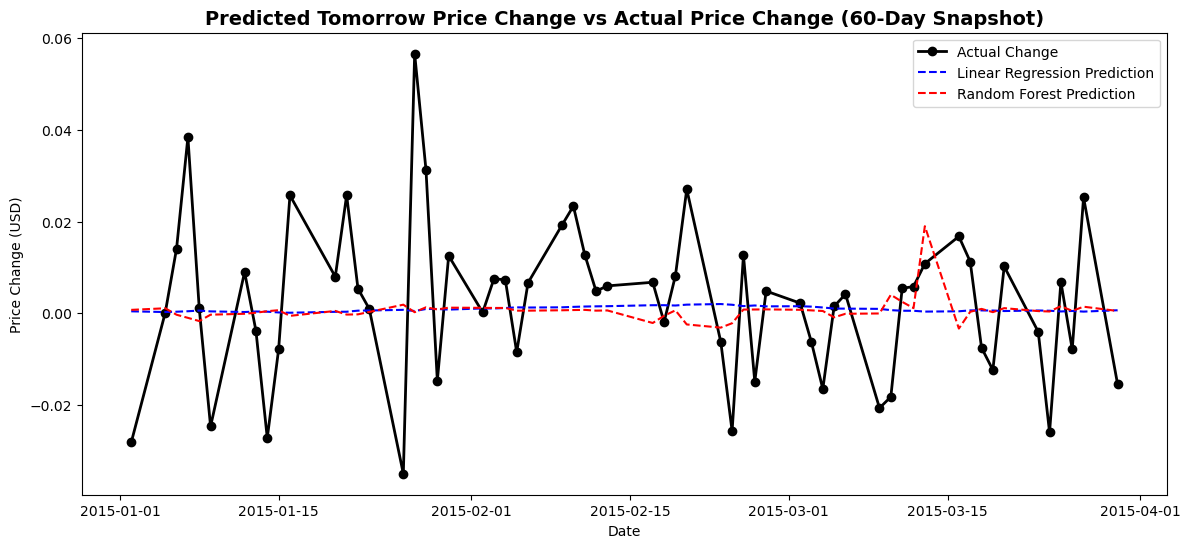

In [7]:
# Grab a 60-day window to make the plot readable
eval_df = pd.DataFrame({'Actual': y_test, 'Linear_Reg': lr_pred, 'Random_Forest': rf_pred}, index=y_test.index)
eval_df_subset = eval_df.iloc[:60]

plt.figure(figsize=(14, 6))
plt.plot(eval_df_subset.index, eval_df_subset['Actual'], label='Actual Change', color='black', linewidth=2, marker='o')
plt.plot(eval_df_subset.index, eval_df_subset['Linear_Reg'], label='Linear Regression Prediction', color='blue', linestyle='--')
plt.plot(eval_df_subset.index, eval_df_subset['Random_Forest'], label='Random Forest Prediction', color='red', linestyle='--')

plt.title('Predicted Tomorrow Price Change vs Actual Price Change (60-Day Snapshot)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price Change (USD)')
plt.legend()
plt.show()


In [8]:
joblib.dump(rf_model , "RF_model")
print("file saved!!!")

file saved!!!
